# Smartphone Price Prediction — End-to-End Machine Learning Pipeline

## Project Overview
This notebook presents a complete machine learning workflow for predicting smartphone prices based on hardware specifications and device characteristics.

The project includes:
- Data loading and preprocessing
- Exploratory data analysis (EDA)
- Feature engineering
- Statistical validation
- Pipeline construction
- Model training and evaluation
- Cross-validation
- Final model serialization for deployment

---

## Objective
The primary objective is to build a robust regression pipeline capable of estimating smartphone market value from technical specifications such as:
- RAM
- CPU frequency
- Camera configuration
- Battery capacity
- Display density
- Internal memory
- Physical dimensions

The final trained pipeline is exported for production usage in the Streamlit application.

## Library Imports

Core machine learning, preprocessing, visualization, and evaluation libraries are imported for the complete workflow.

In [1]:
# Core dependencies for data analysis, visualization, preprocessing, and model training
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

import warnings
warnings.filterwarnings('ignore')

d:\assignment5\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Loading

The smartphone dataset is downloaded directly from Kaggle and loaded into a pandas dataframe for analysis.

In [2]:
# Download and load the smartphone pricing dataset
path = kagglehub.dataset_download("mohannapd/mobile-price-prediction")
df = pd.read_csv(path + "/Cellphone.csv")

## Dataset Dimensions

The dataset shape helps validate the number of records and available features before preprocessing begins.

In [3]:
# Inspect dataset dimensions
df.shape

(161, 14)

## Dataset Information

Data types, memory usage, and non-null counts are inspected to understand the structure of the dataset.

In [4]:
# Review dataframe structure and feature data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


## Missing Value Analysis

This step verifies whether the dataset contains missing values that require preprocessing or imputation.

In [5]:
# Check for missing values across all columns
df.isnull().sum()

Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

## Statistical Summary

Descriptive statistics provide insight into the distribution and scale of numerical features.

In [6]:
# Generate descriptive statistical summary
df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


## Duplicate Record Validation

Duplicate entries are checked to ensure data quality and consistency.

In [7]:
# Identify duplicated observations
print('Duplicated rows:' , df.duplicated().sum())

Duplicated rows: 0


## Random Dataset Sampling

Random samples are displayed to better understand feature formatting and raw observations.

In [8]:
# Preview random observations from the dataset
df.sample(7)

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
57,93,1984,57,154.0,5.0,294,4,1.00,8.0,1.0,8.0,5.0,3140,8.1
58,739,1989,57,131.0,5.0,294,4,1.30,16.0,2.0,13.0,5.0,2500,8.7
123,1327,2001,399,194.8,5.7,258,4,1.20,16.0,2.0,8.0,1.0,3400,10.2
90,237,1646,141,404.0,8.0,160,4,1.20,8.0,1.0,5.0,5.0,4500,9.0
91,131,1831,143,154.0,5.0,294,4,1.20,8.0,1.0,13.0,5.0,2100,8.4
133,497,2266,599,112.0,5.0,294,8,1.40,8.0,1.0,8.0,8.0,1900,6.3
60,563,2824,58,175.0,5.5,401,6,1.53,32.0,3.0,21.0,8.0,3500,9.3


## Train-Test Split

The dataset is separated into training and testing subsets to evaluate generalization performance.

In [9]:
# Split dataset into training and testing sets

X = df.drop(columns=['Price'])
Y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size= 0.30, random_state= 101)

train_df = x_train.copy()
train_df['Price'] = y_train
test_df = x_test.copy()
test_df['Price'] = y_test

print('Train:', train_df.shape)
print('Test:', test_df.shape)

print('\n\nTotal (zero) values in each data column:')
print('\nTraining Data:\n', (train_df == 0).sum().to_frame().T)
print('\nTesting Data:\n', (test_df == 0).sum().to_frame().T)

print('\n\nTraining Data (Medians):')
train_df.median()

Train: (112, 14)
Test: (49, 14)


Total (zero) values in each data column:

Training Data:
    Product_id  Sale  weight  resoloution  ppi  cpu core  cpu freq  \
0           0     0       0            0    0         6         6   

   internal mem  ram  RearCam  Front_Cam  battery  thickness  Price  
0             7    1        6         27        0          0      0  

Testing Data:
    Product_id  Sale  weight  resoloution  ppi  cpu core  cpu freq  \
0           0     0       0            0    0         4         4   

   internal mem  ram  RearCam  Front_Cam  battery  thickness  Price  
0             3    1        2         15        0          0      0  


Training Data (Medians):


Product_id       768.500
Sale              97.000
weight           152.500
resoloution        5.175
ppi              294.000
cpu core           4.000
cpu freq           1.400
internal mem      16.000
ram                2.000
RearCam           12.000
Front_Cam          5.000
battery         2800.000
thickness          8.400
Price           2266.000
dtype: float64

## Custom Feature Engineering Transformer

A custom preprocessing transformer is created to handle:
- Zero-value replacement
- Median-based imputation
- Feature engineering
- Column cleanup

This transformer becomes part of the final production pipeline.

In [10]:
# Custom transformer for feature engineering and preprocessing
    

class Custom_Transform(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        self.medians_ = X.replace(0, np.nan).median()
            
        return self
    
    def transform(self, X):
        x_new = X.copy()
        
        x_new = x_new.replace(0, np.nan).fillna(self.medians_)

        x_new['performance_score'] = x_new['cpu freq'] * x_new['cpu core'] * x_new['ram']
        x_new['display_quality'] = x_new['ppi'] * x_new['resoloution']
        x_new['ram_mem'] = x_new['ram'] * x_new['internal mem']
        
        remove_cols = ['Price', 'Product_id', 'Sale']
        all_cols = list(x_new.columns)
        
        for col in remove_cols:
            if col in all_cols:
                x_new = x_new.drop(columns=[col])

        return x_new

custom_transform = Custom_Transform().fit(train_df)
train_df = custom_transform.transform(train_df)
test_df = custom_transform.transform(test_df)

## Distribution & Outlier Analysis

Feature distributions and boxplots are visualized to identify skewness, spread, and potential outliers.

In [11]:
# Visualize feature distributions and outliers
train_df.skew()

weight               3.657880
resoloution          1.329440
ppi                  0.542926
cpu core             0.456575
cpu freq             0.385720
internal mem         2.434071
ram                  0.826635
RearCam              0.098998
Front_Cam            1.537430
battery              2.107529
thickness            1.556307
performance_score    1.689007
display_quality      0.191998
ram_mem              2.887950
dtype: float64

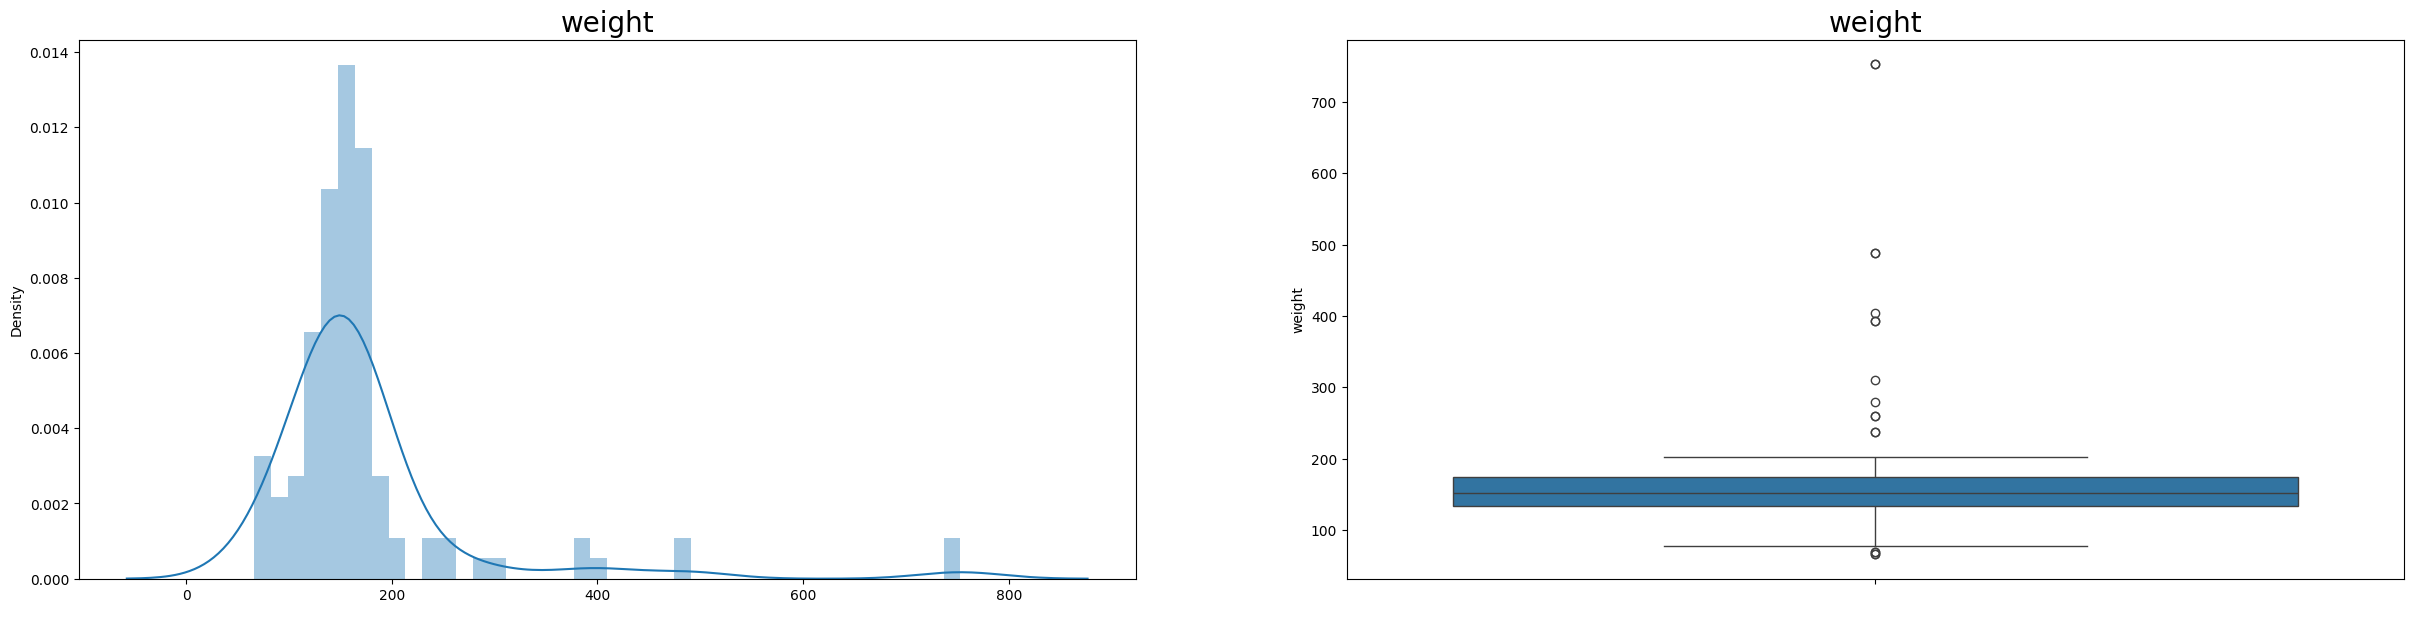

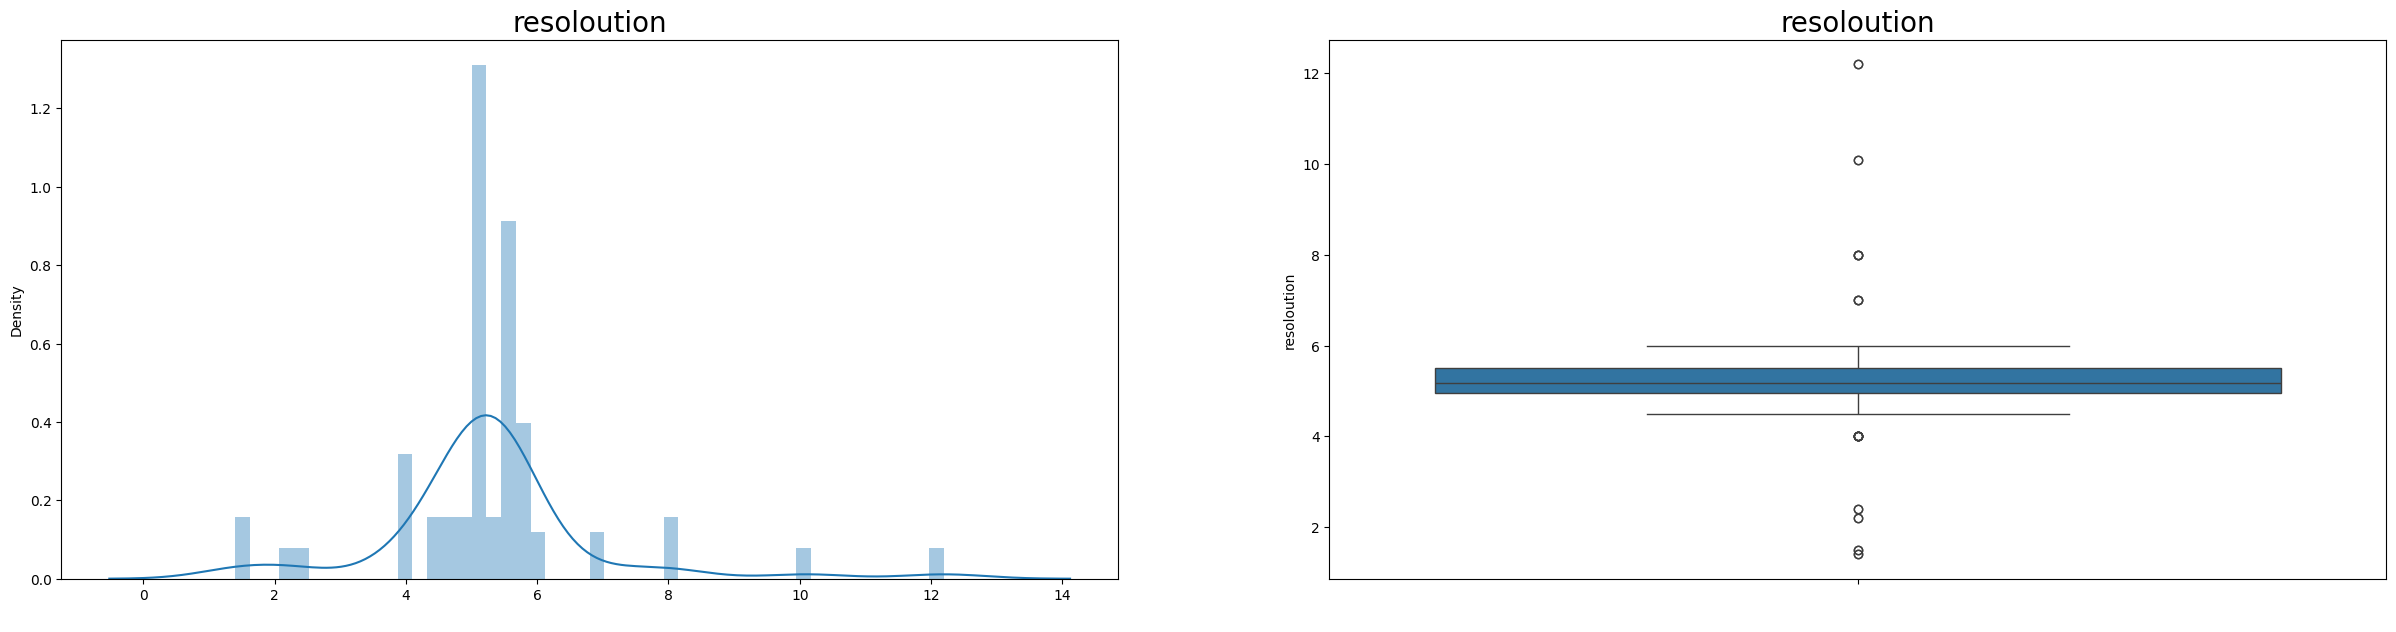

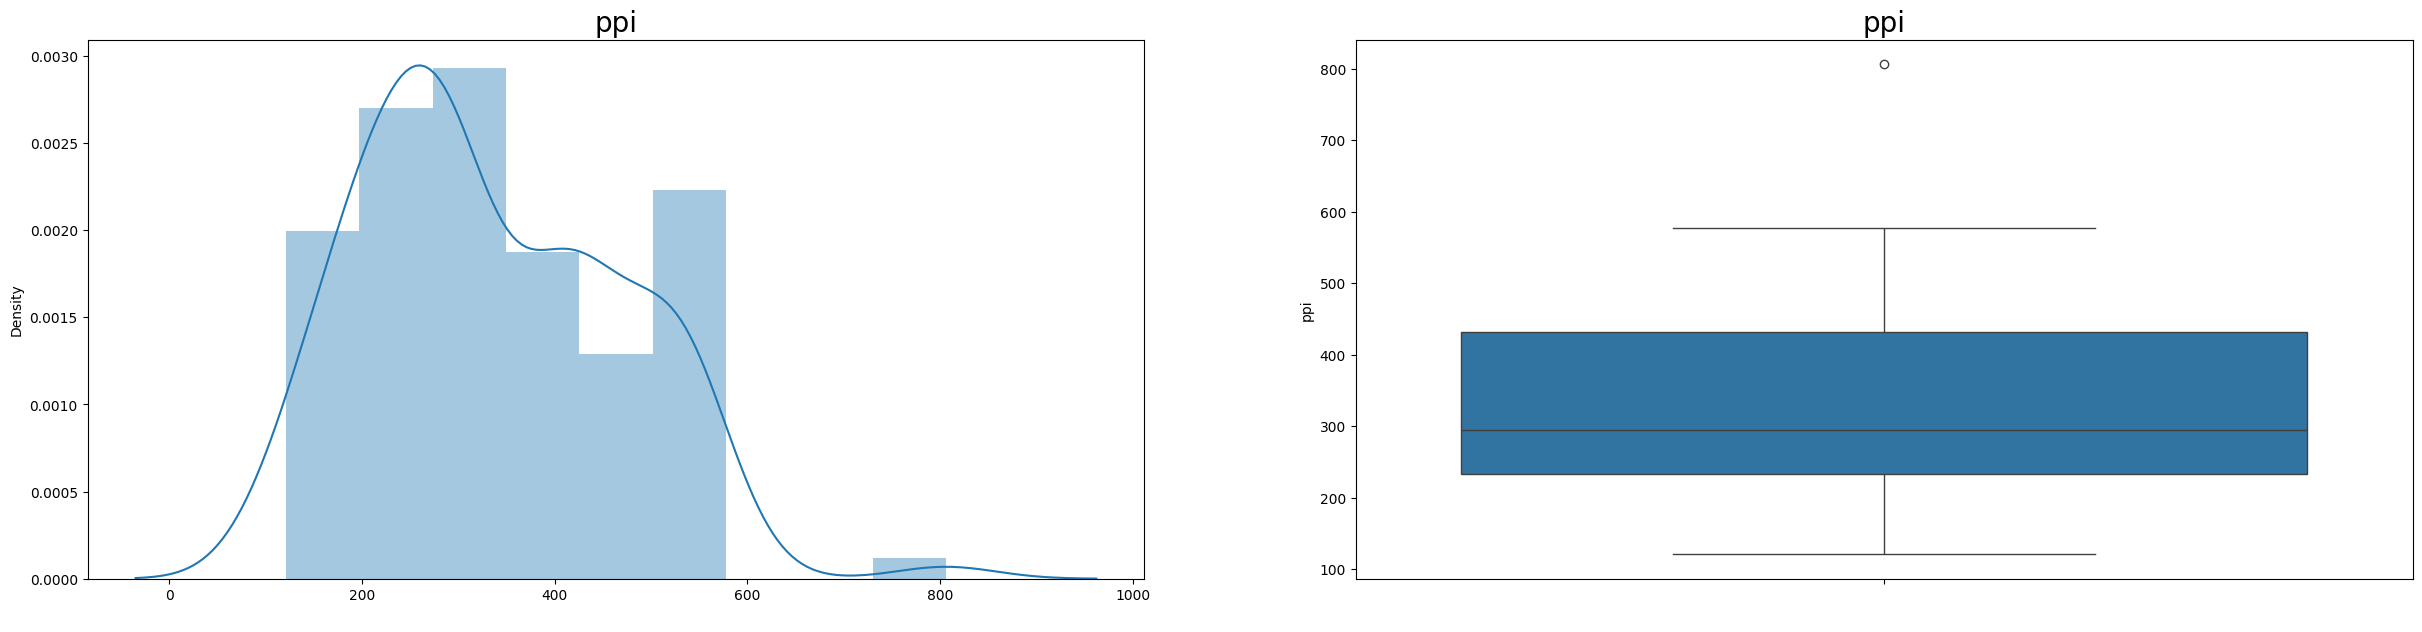

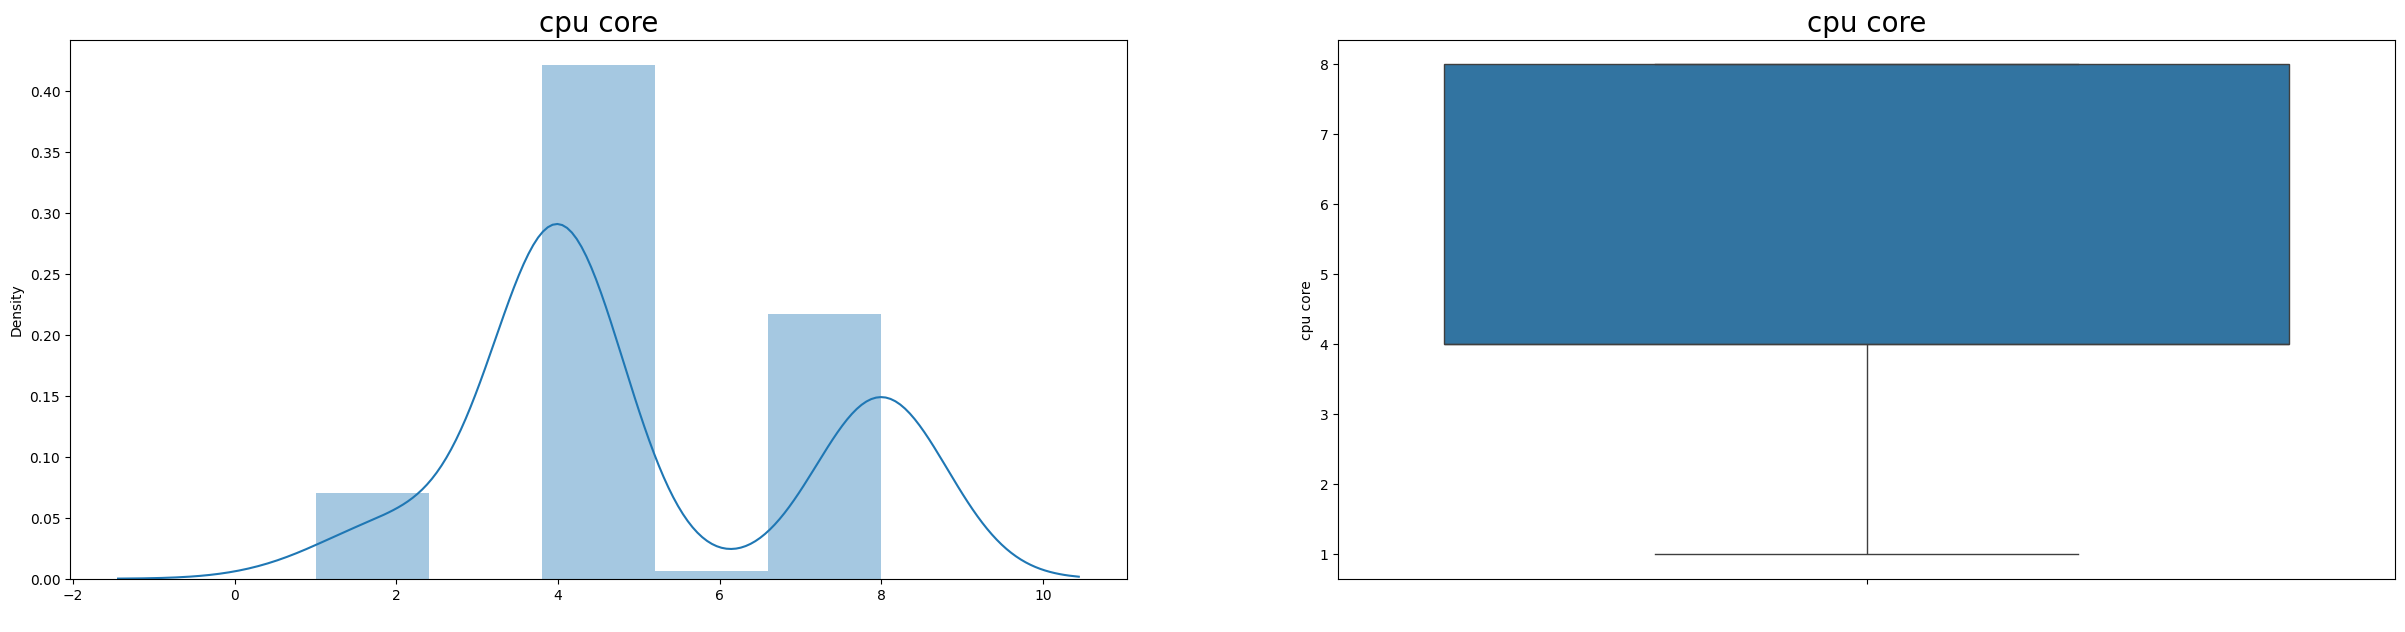

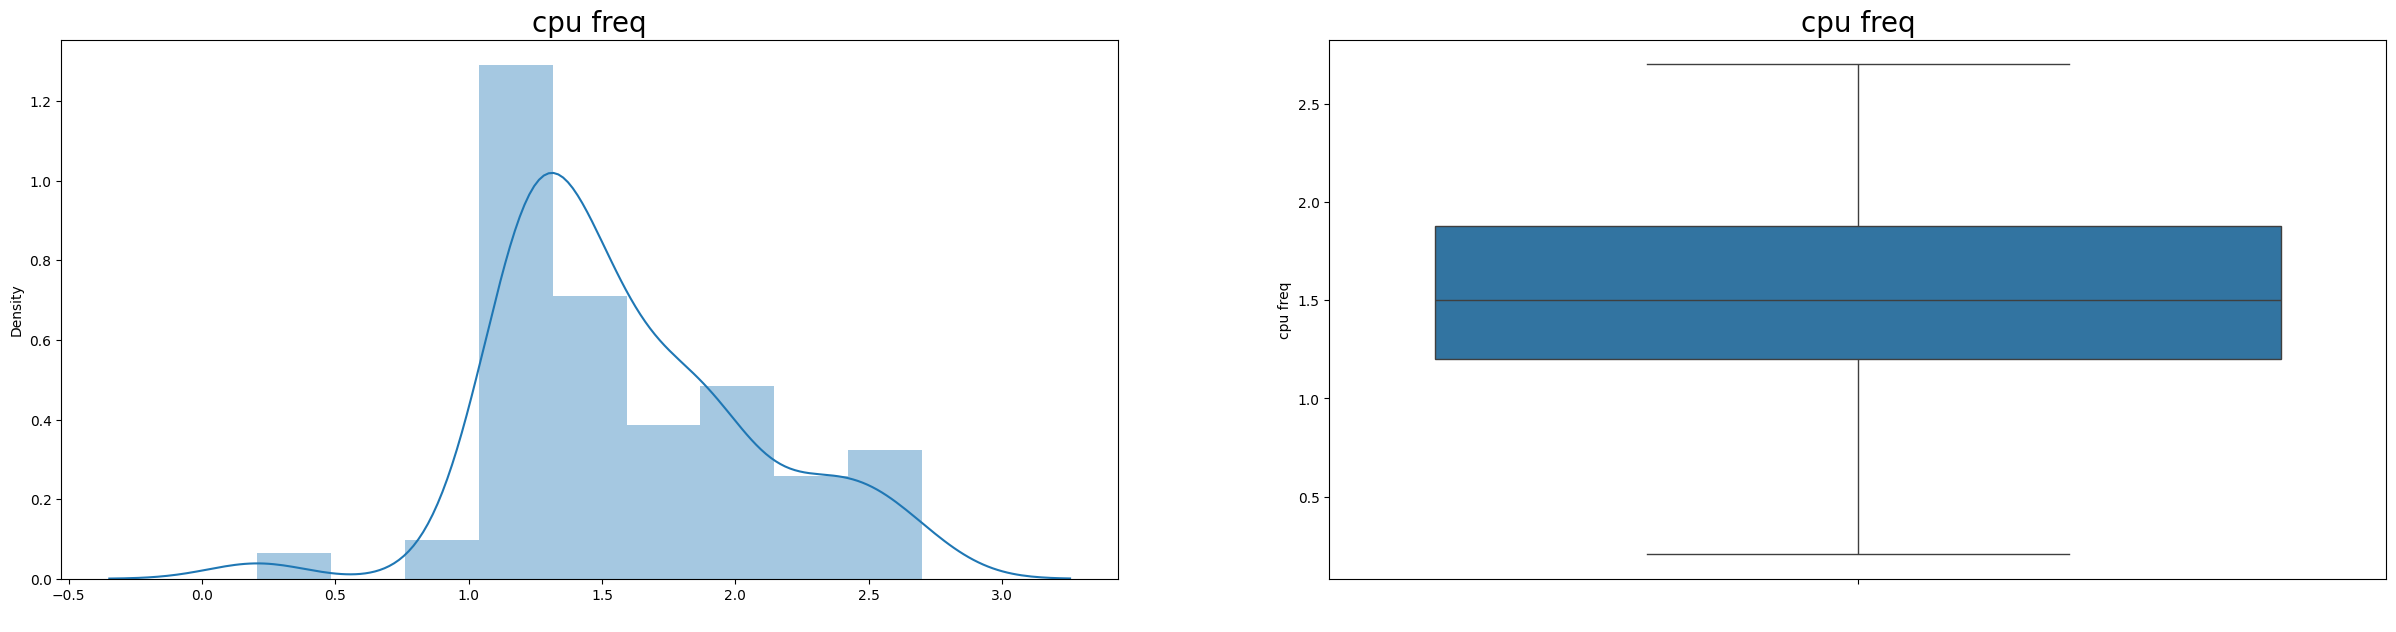

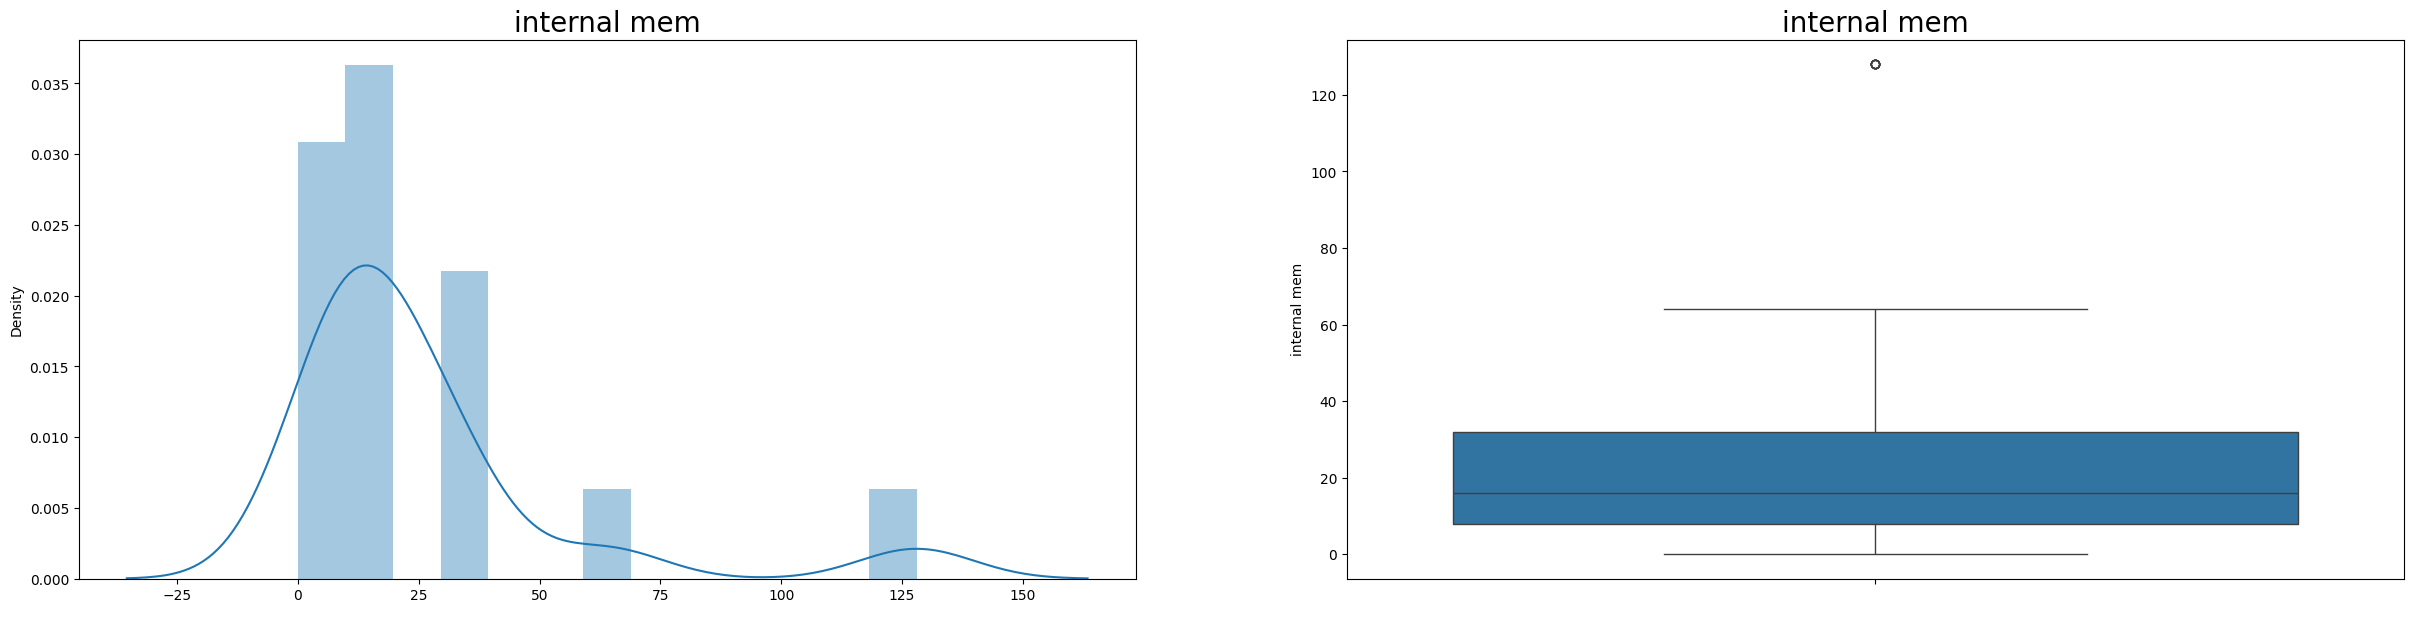

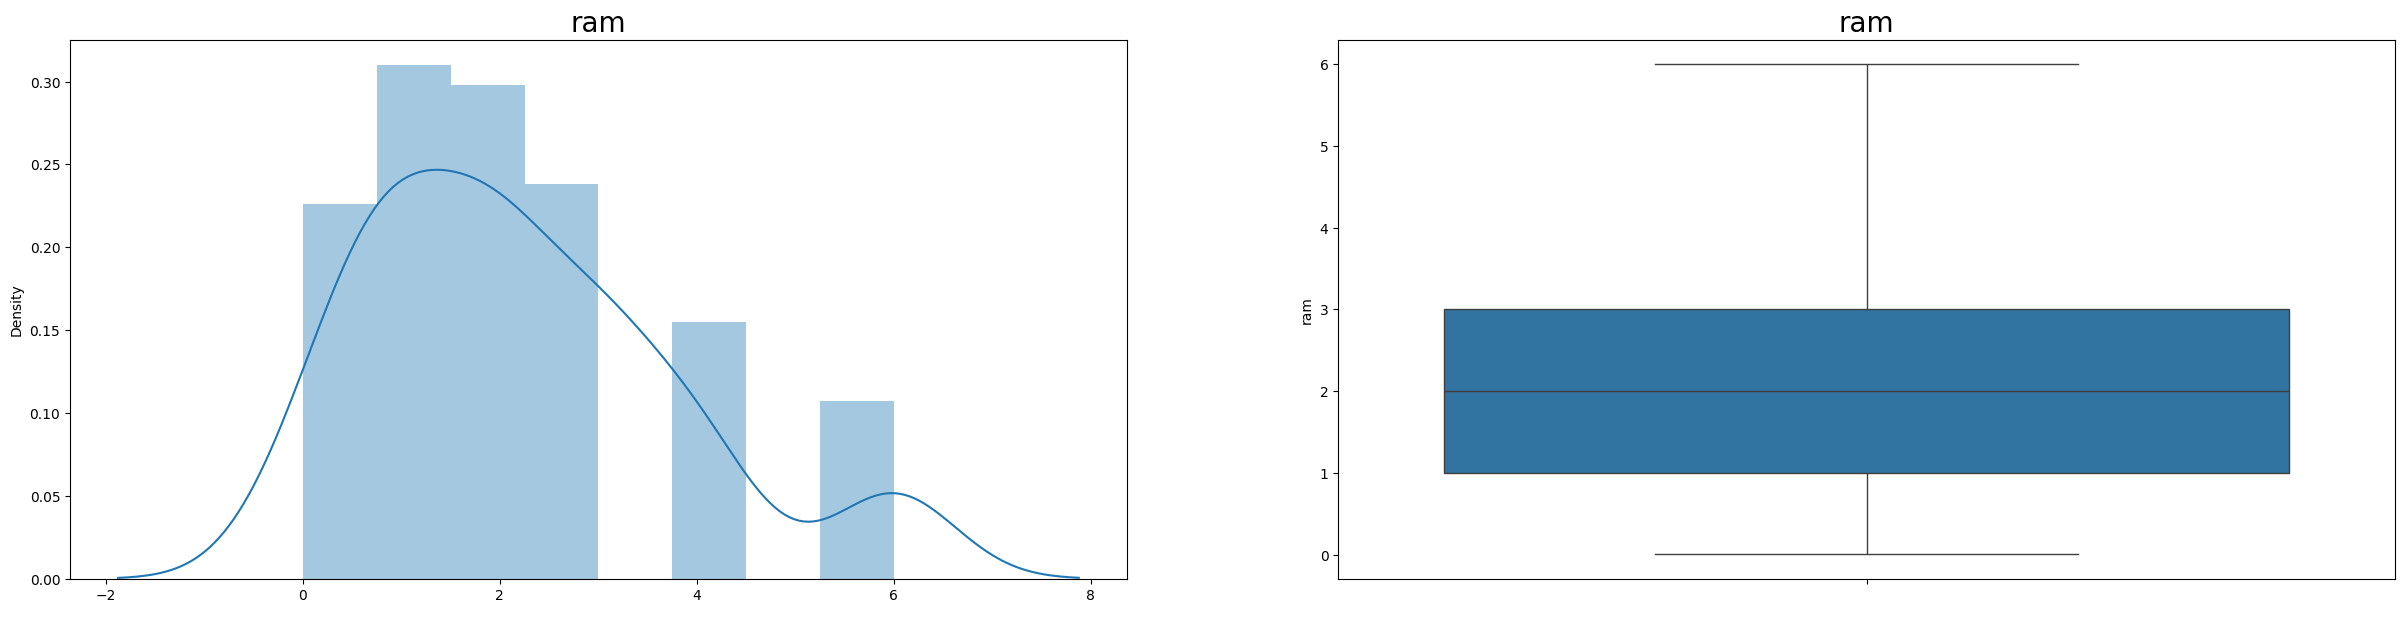

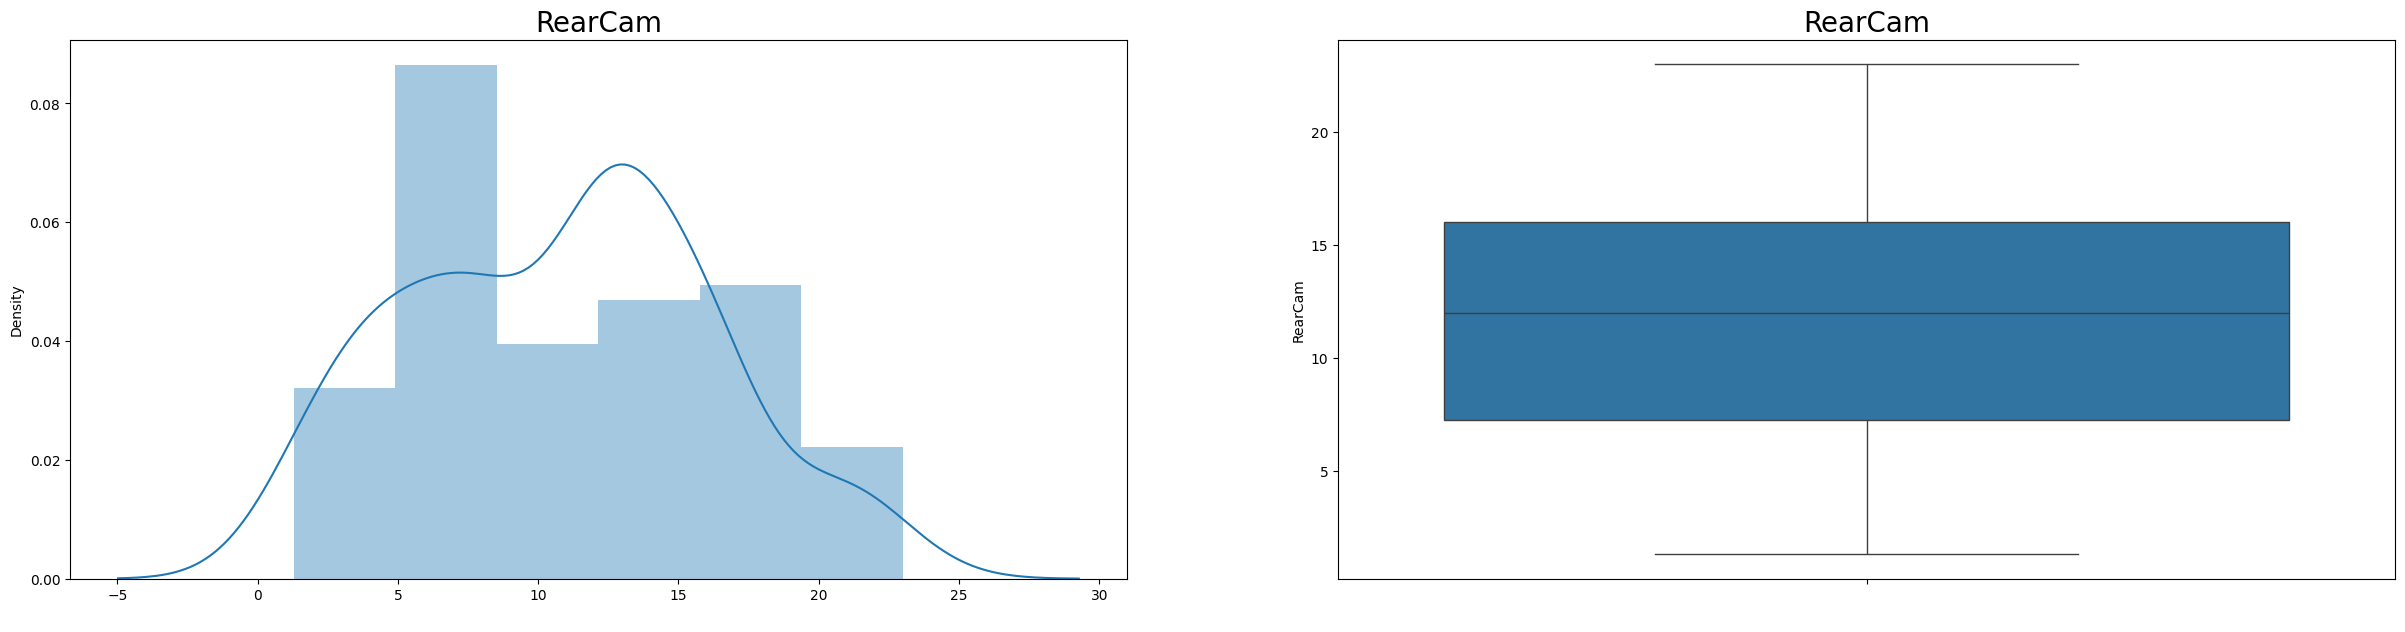

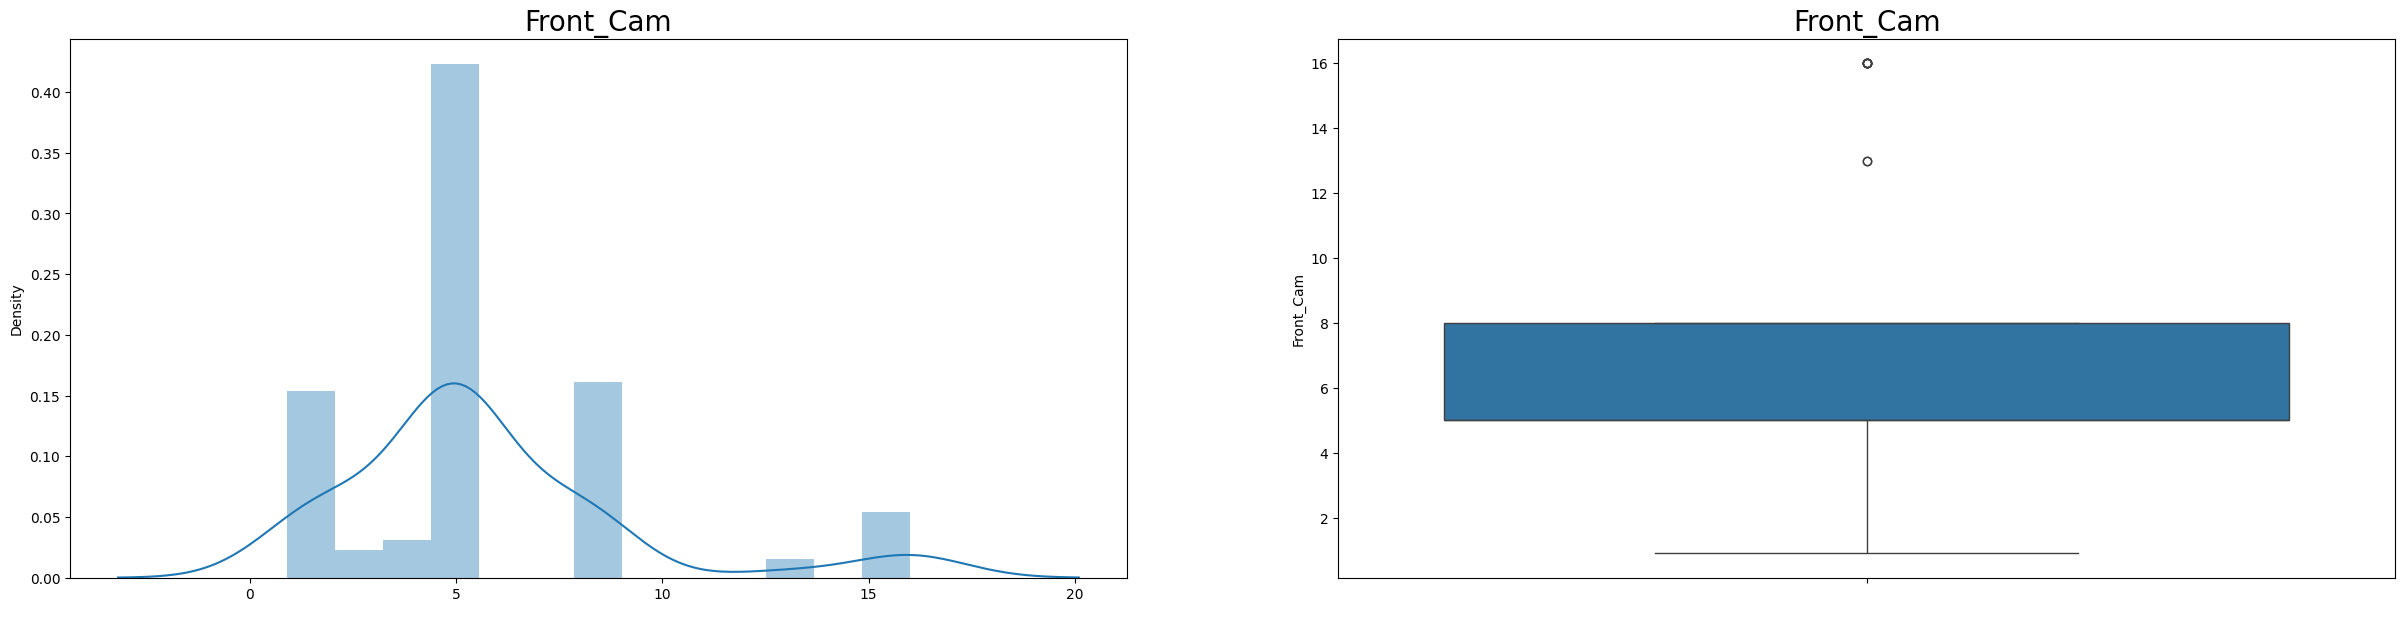

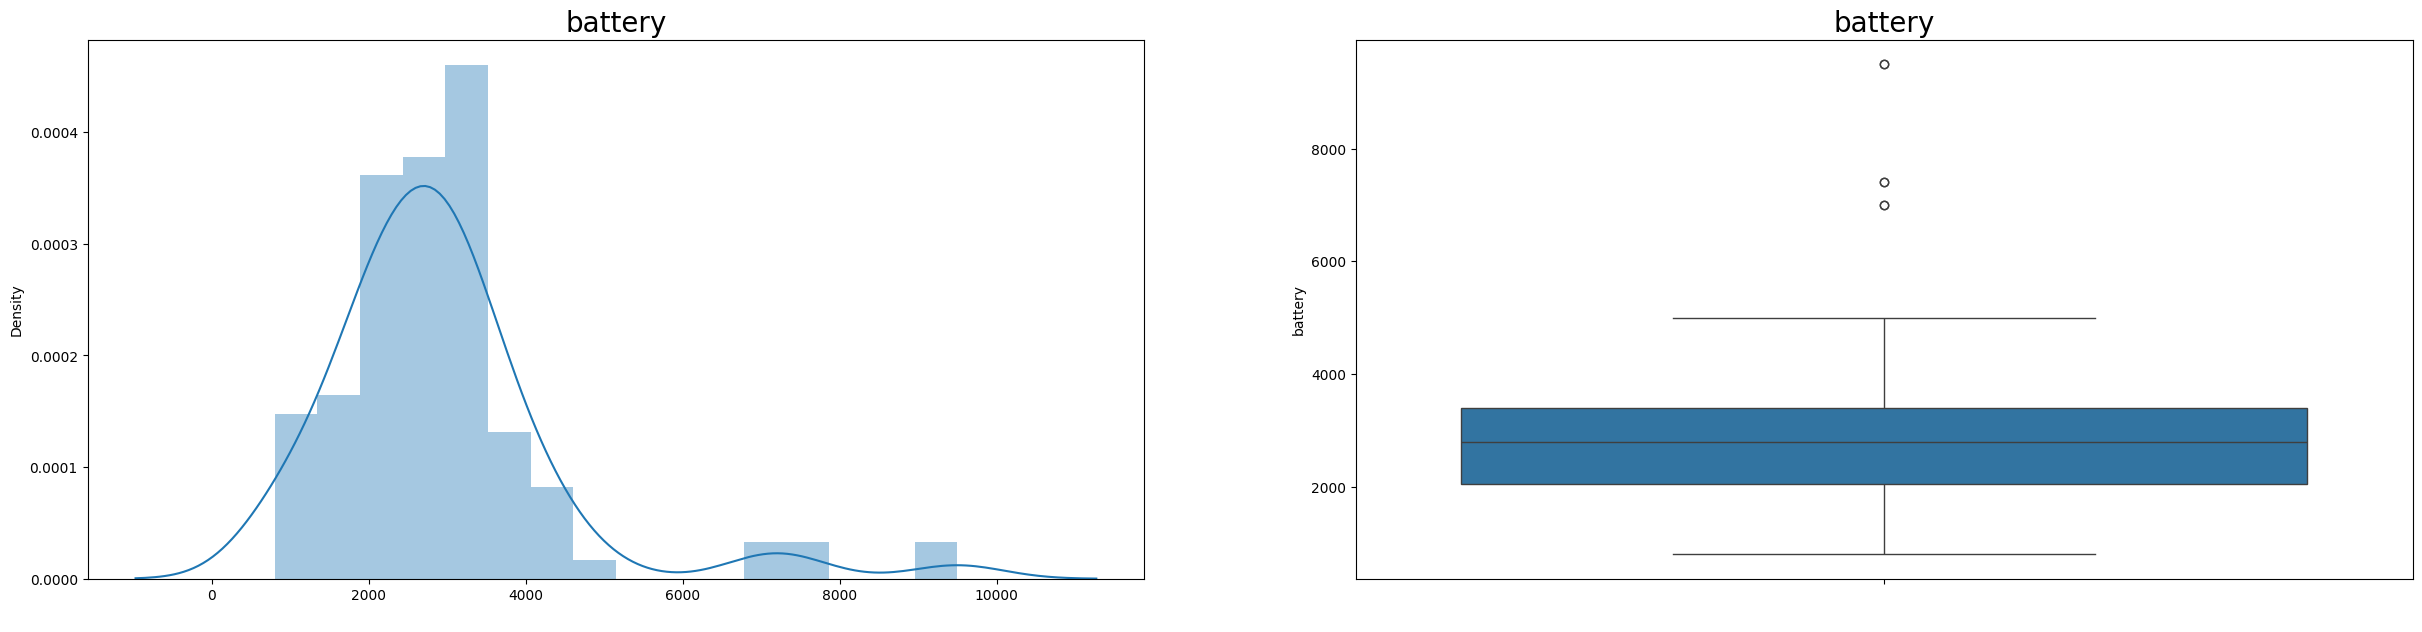

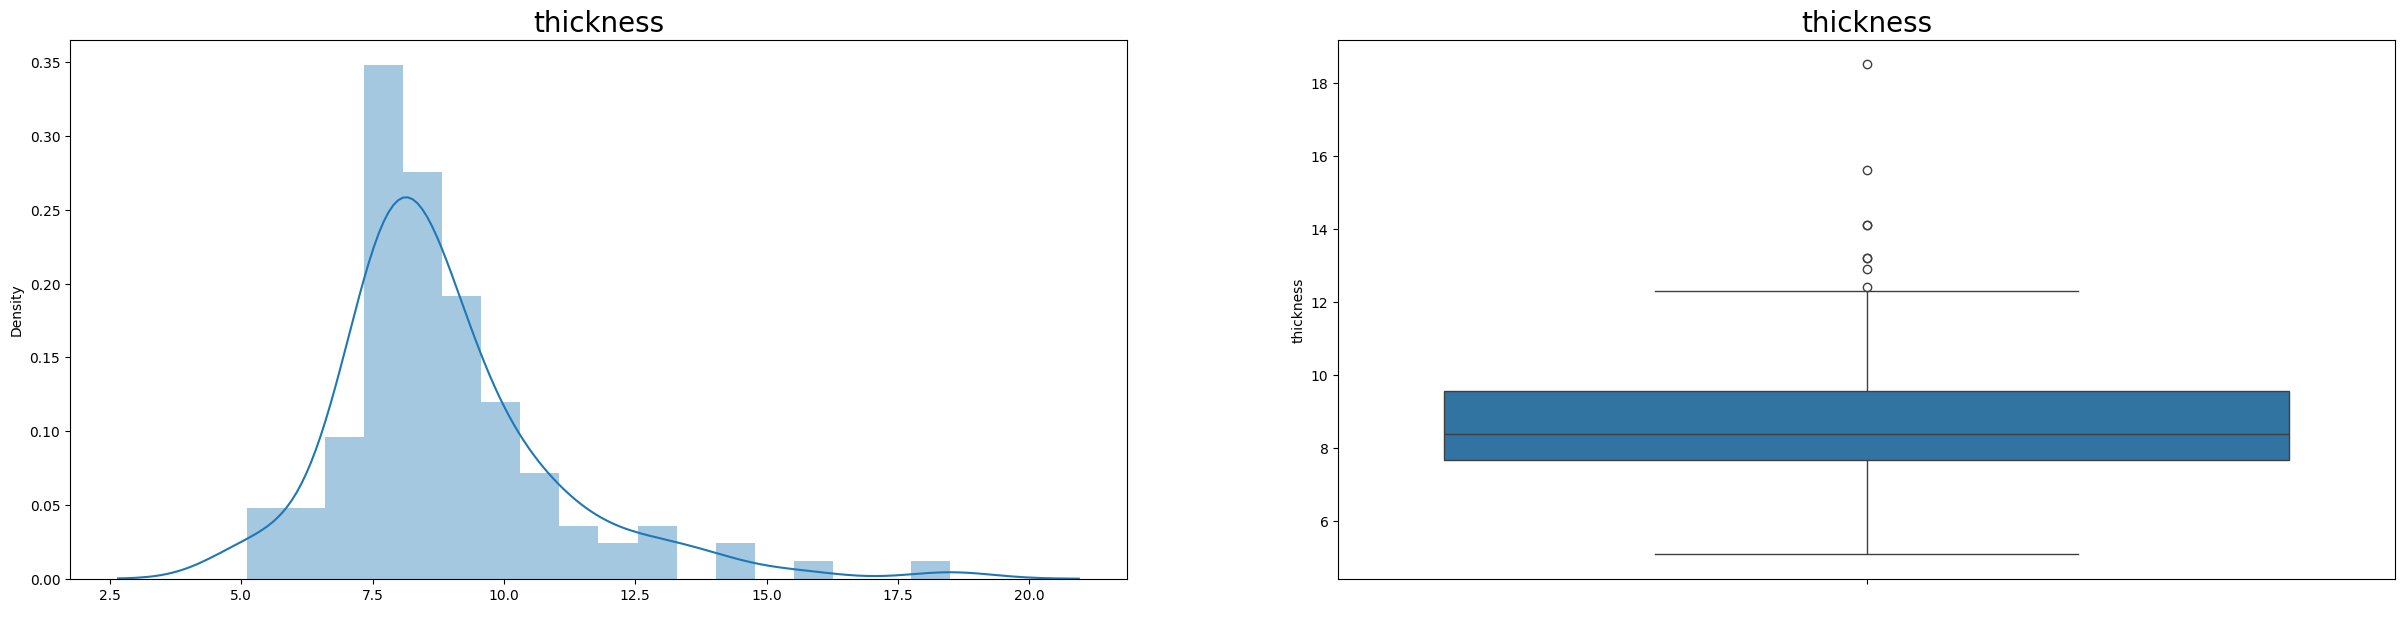

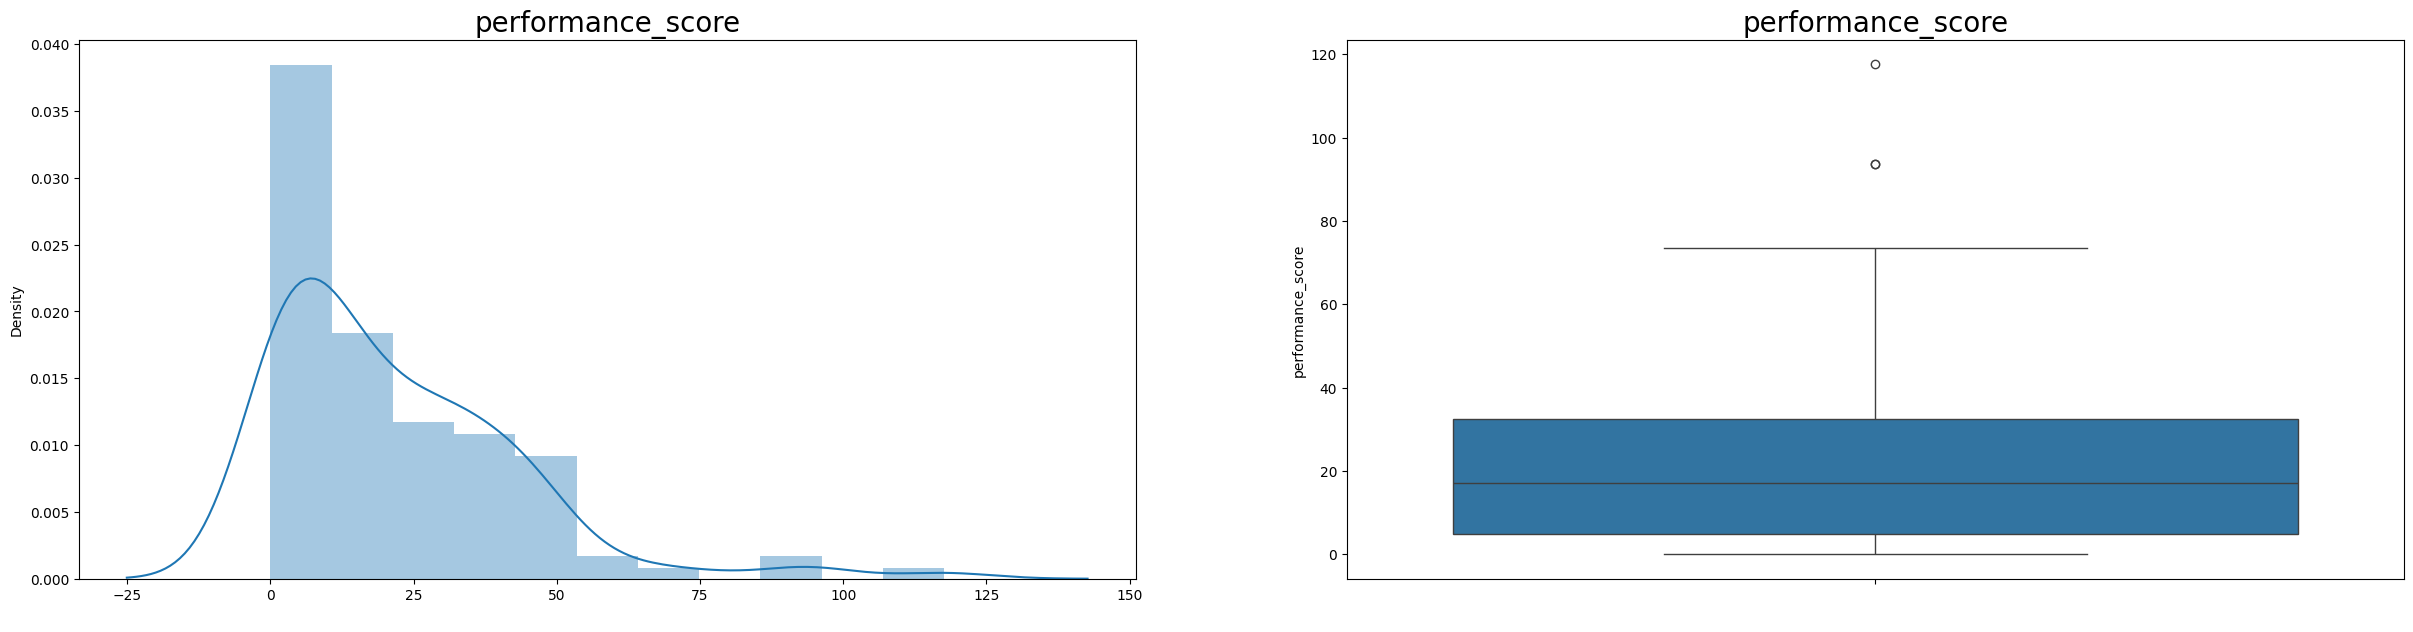

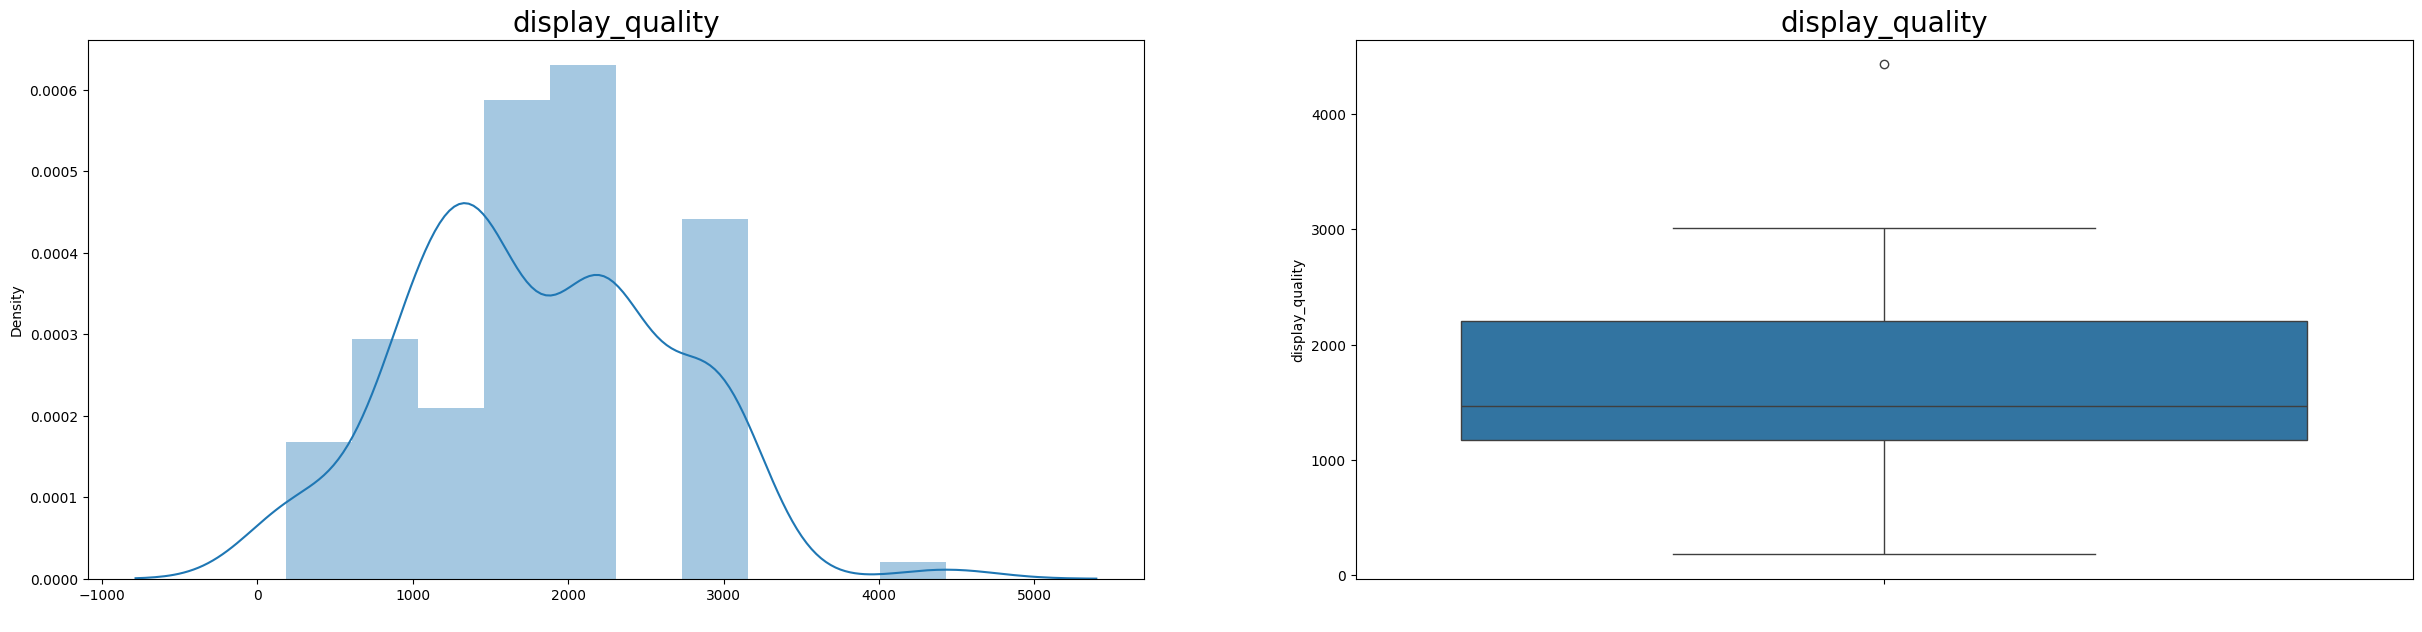

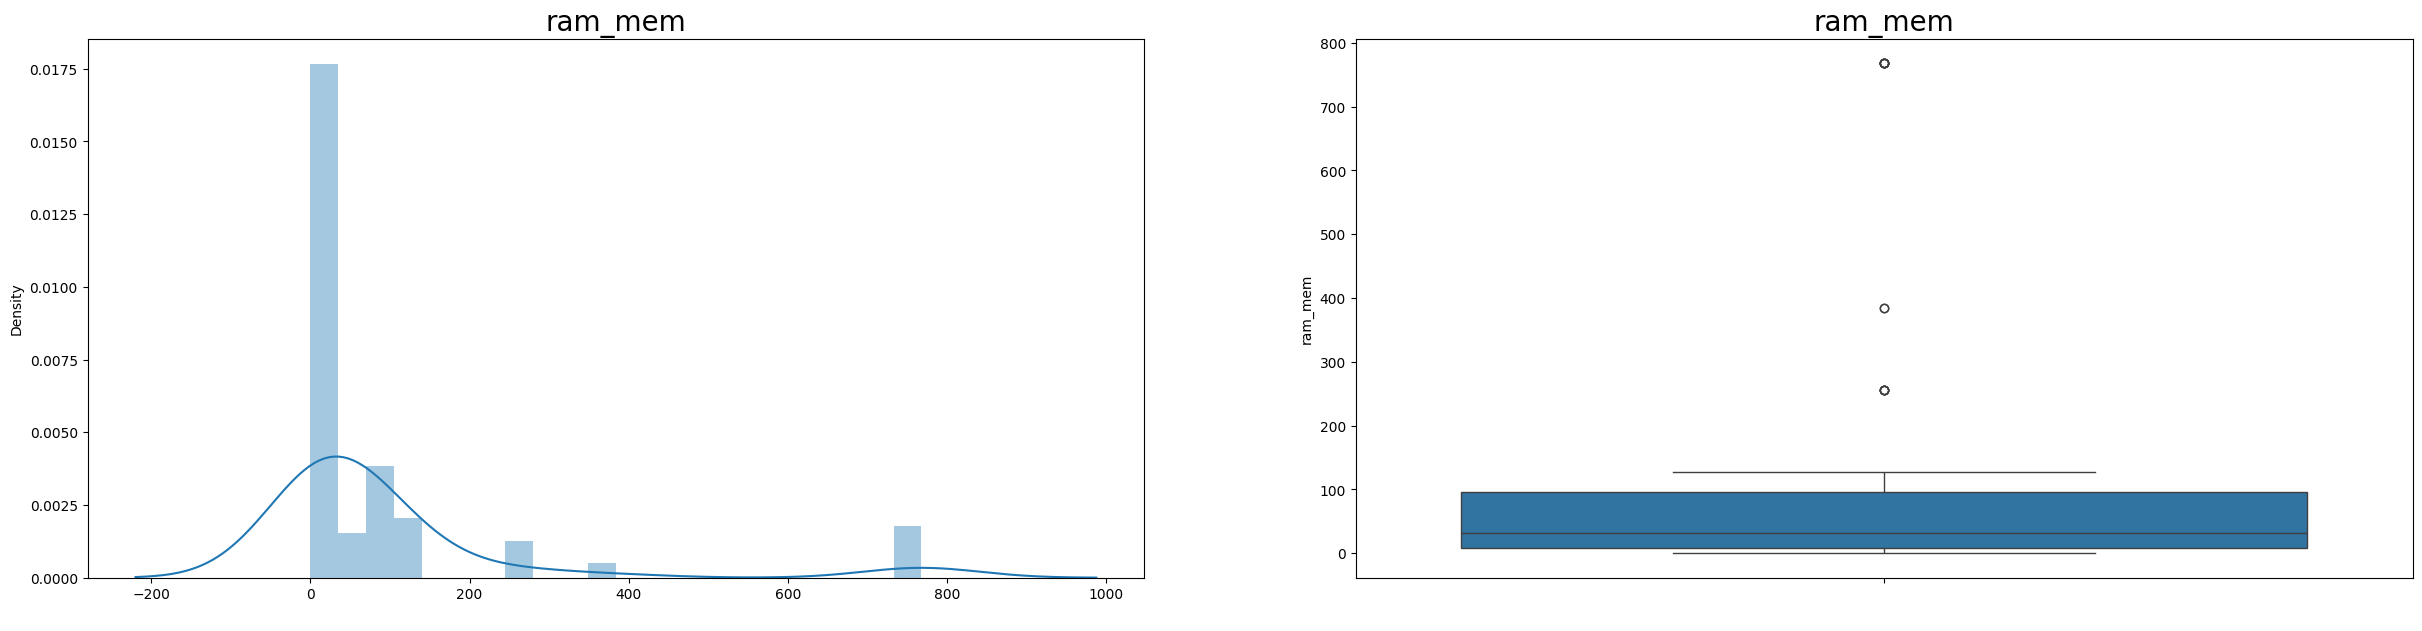

In [12]:
for col in train_df.columns:
    plt.figure(figsize = (30,7))
    plt.subplot(1,2,1)
    sns.distplot(train_df[col])
    plt.xlabel(" ")

    plt.title(col, size = 20)
    
    plt.subplot(1,2,2)
    sns.boxplot(y = train_df[col])
    plt.title(col, size = 20)
    plt.show()

## Feature Relationship Analysis

Pairplots are used to study relationships between hardware specifications and smartphone pricing.

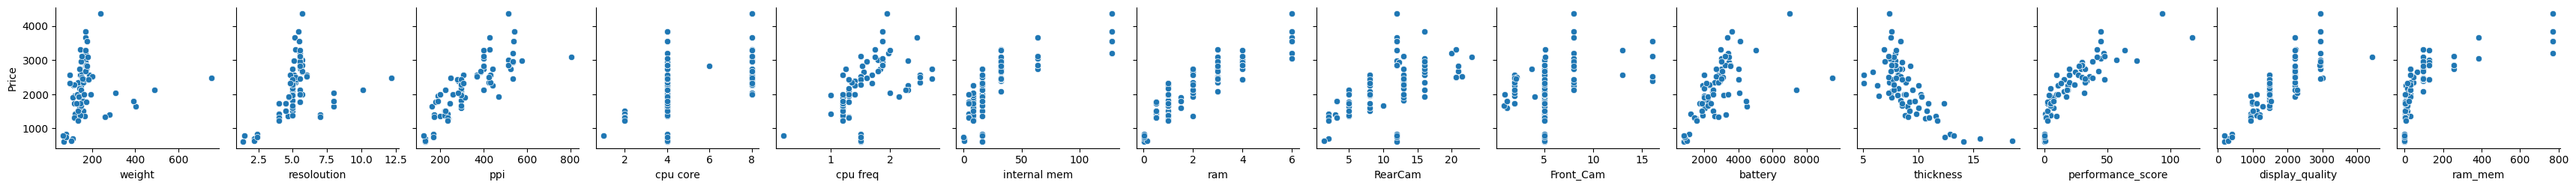

In [13]:
# Analyze pairwise relationships with target variable
train_df['Price'] = y_train
sns.pairplot(train_df, x_vars=train_df.drop(columns=['Price']), y_vars=['Price'])
plt.show()

## Correlation Matrix

The correlation heatmap highlights positive and negative linear relationships between features.

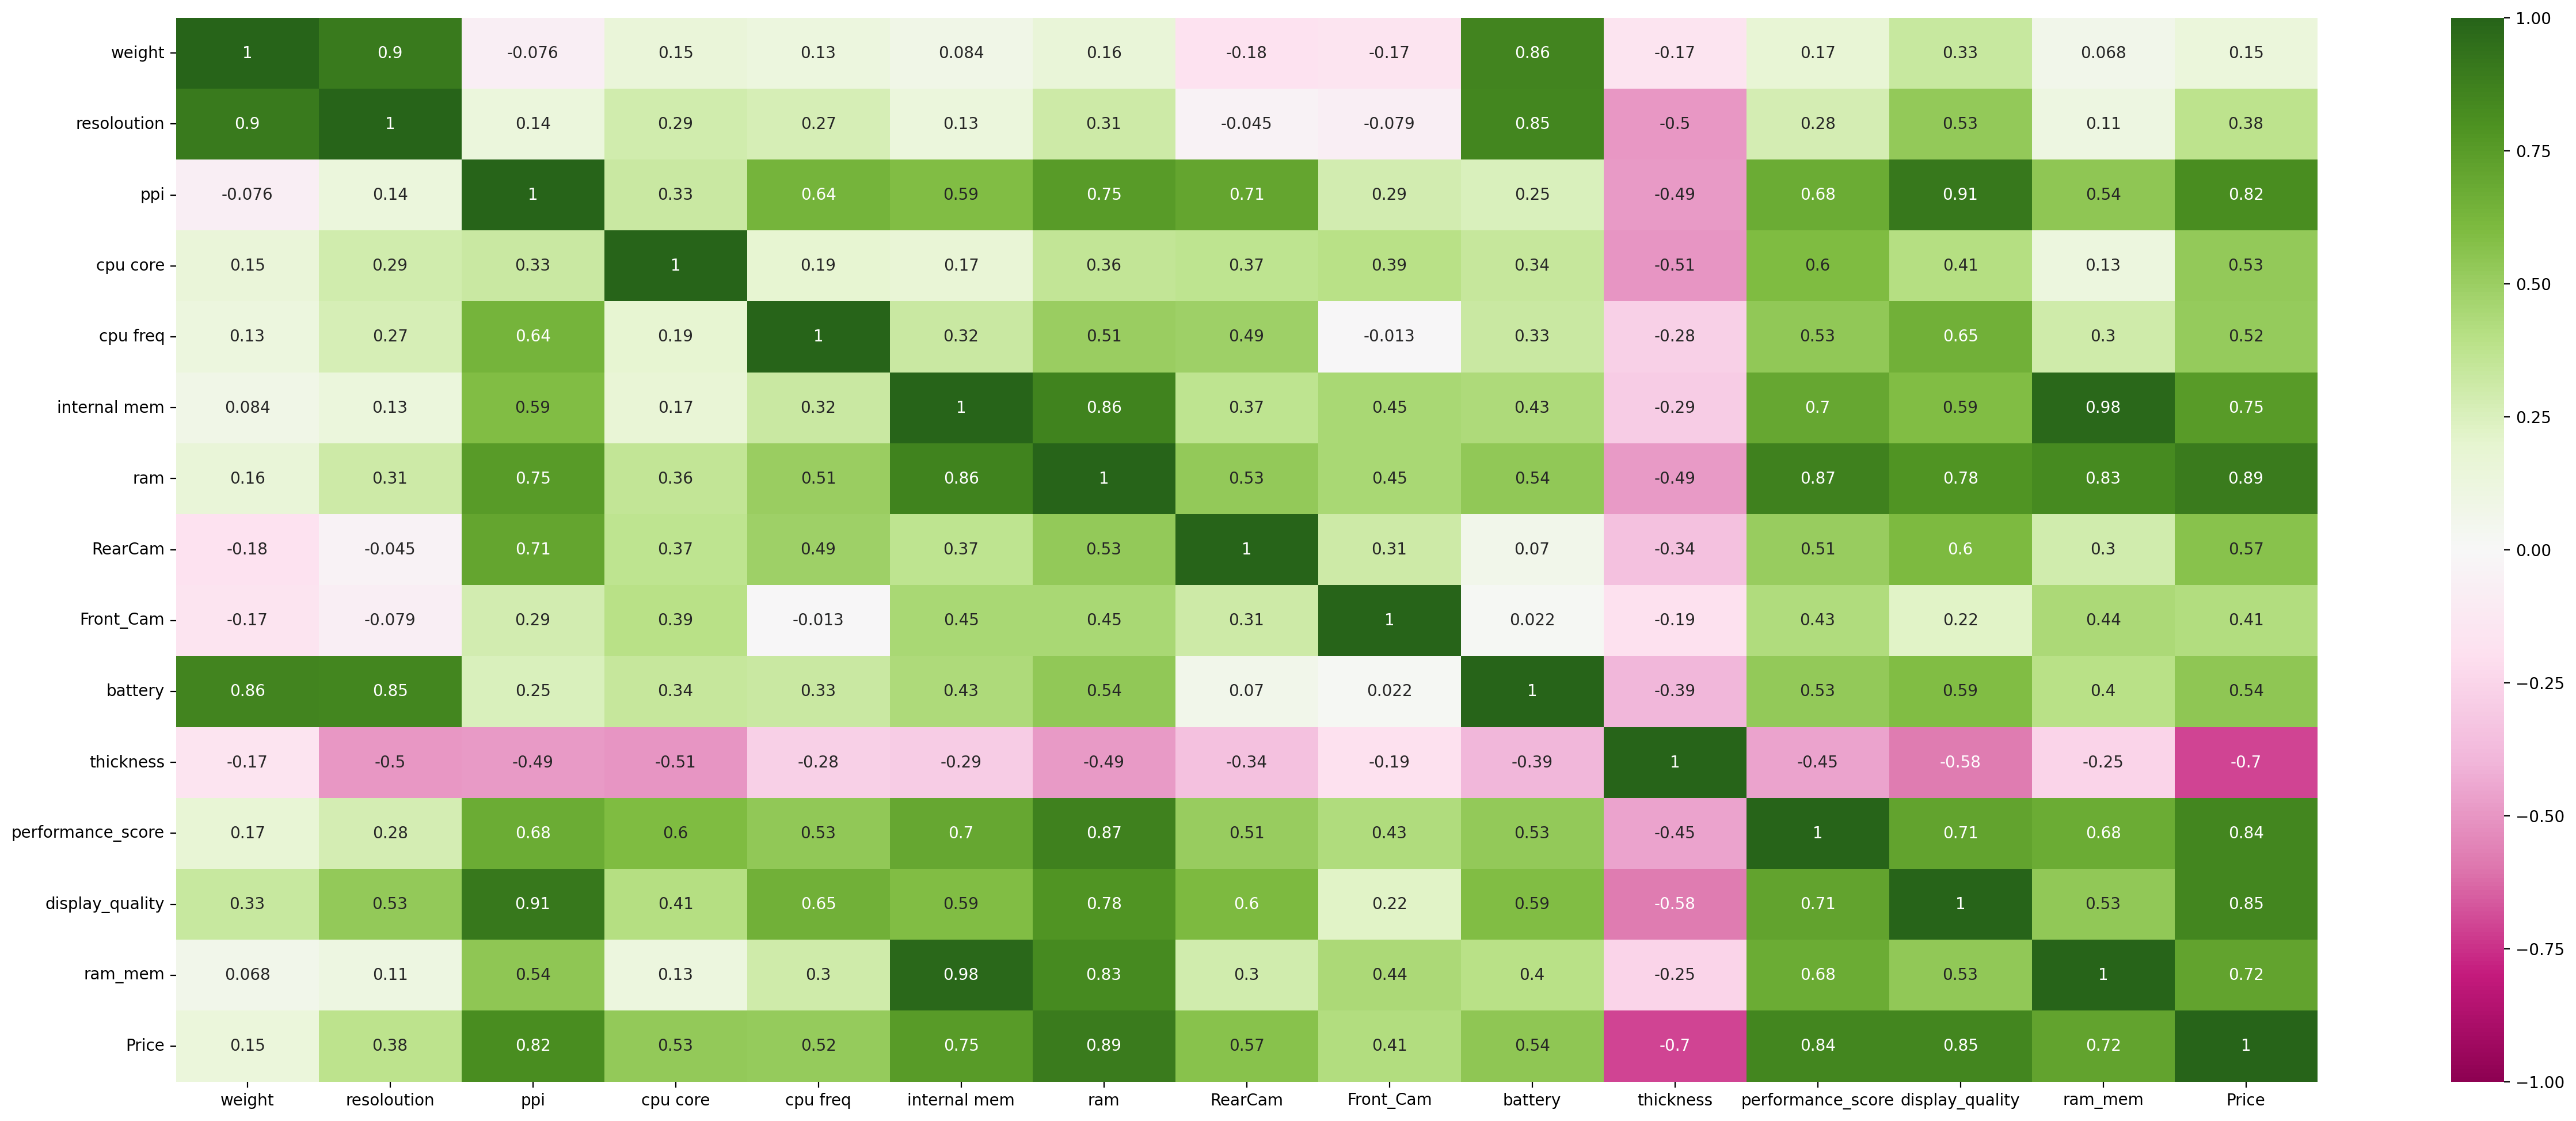

In [14]:
# Visualize feature correlations
plt.figure(figsize = (30,12), dpi = 200)
sns.heatmap(train_df.corr(), annot = True, vmin = -1, vmax = +1, cmap = "PiYG")
plt.show()

## Multicollinearity Check (VIF)

Variance Inflation Factor (VIF) analysis is performed to identify highly correlated predictors.

In [15]:
# Calculate variance inflation factors
from statsmodels.tools.tools import add_constant

X = train_df

X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

print(vif_data)

              feature         VIF
0               const  649.039562
1              weight   33.814607
2         resoloution   41.100920
3                 ppi  120.821067
4            cpu core    3.396305
5            cpu freq    2.474538
6        internal mem   56.006225
7                 ram   15.742268
8             RearCam    2.953664
9           Front_Cam    1.960263
10            battery   14.708663
11          thickness    5.780273
12  performance_score    9.890068
13    display_quality  154.890155
14            ram_mem   47.053352
15              Price   23.334706


In [16]:
x_train.skew()

Product_id     -0.231892
Sale            4.419464
weight          3.657880
resoloution     1.329440
ppi             0.542926
cpu core        0.073719
cpu freq       -0.430596
internal mem    2.359310
ram             0.815634
RearCam         0.068374
Front_Cam       1.136738
battery         2.107529
thickness       1.556307
dtype: float64

In [17]:
x_test.skew()

Product_id     -0.185866
Sale            4.075690
weight          2.805519
resoloution    -0.414732
ppi             0.744057
cpu core       -0.180193
cpu freq       -0.703795
internal mem    2.219402
ram             0.758568
RearCam         0.113738
Front_Cam       1.274088
battery         0.010759
thickness       1.622393
dtype: float64

## Power Transformation Setup

Box-Cox transformations are configured for skewed features to stabilize variance and improve linear model performance.

In [18]:
# Configure Box-Cox transformations for skewed features
trans_cols = ['internal mem', 'weight', 'thickness', 'performance_score']

transform = ColumnTransformer(
    transformers=[(
        'box-cox',
        PowerTransformer('box-cox', standardize= False),
        trans_cols
)],
    remainder='passthrough'
)

## Machine Learning Pipeline Construction

A reusable sklearn pipeline is built to combine preprocessing, scaling, and regression models into a single workflow.

In [19]:
# Build reusable machine learning pipeline
pipeline = Pipeline([
    ('custom_transform', Custom_Transform()),
    ('transform', transform),
    ('scaler', StandardScaler()),
    ('model', None)
])

## Model Training & Evaluation

Multiple regression algorithms are trained and evaluated using:
- RMSE
- MAE
- R² score

Both training and testing performance are compared to assess generalization.

In [20]:
# Train and evaluate multiple regression models
models = {'Linear Regression': LinearRegression(), 'Ridge': Ridge(alpha=10.0), 'Lasso': Lasso(alpha=1.0), 'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5)}

prediction_metrics = pd.DataFrame(columns=['Model', 'Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R2', 'Test R2'])

for model_name, model in models.items():
    pipeline.set_params(model=model)
    model_pipeline = pipeline.fit(x_train, y_train)
    test_predictions = model_pipeline.predict(x_test)
    train_predictions = model_pipeline.predict(x_train)

    test_mae = mean_absolute_error(y_test, test_predictions)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    test_r2 = r2_score(y_test, test_predictions)
    
    train_mae = mean_absolute_error(y_train, train_predictions)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    train_r2 = r2_score(y_train, train_predictions)
    
    prediction_metrics.loc[len(prediction_metrics)] = [model_name, train_rmse, test_rmse, train_mae, test_mae, train_r2, test_r2]

prediction_metrics = prediction_metrics.sort_values(by='Test R2', ascending= False).set_index('Model')
prediction_metrics

,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
Model,,,,,,
Linear Regression,155.423726,191.390458,120.273624,163.248246,0.959591,0.934570
Lasso,156.876964,195.584092,123.572590,167.619373,0.958832,0.931671
Ridge,172.590902,201.945643,139.918450,171.805306,0.950171,0.927154
ElasticNet,200.726756,203.752442,159.730320,166.472087,0.932601,0.925845


## Cross-Validation Analysis

Cross-validation is used to evaluate model stability and reduce the risk of overfitting.

In [21]:
# Perform k-fold cross-validation

scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    }

cvs_metrics = pd.DataFrame(columns=['Model', 'Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R2', 'Test R2'])

for model_name, model in models.items():
    results = cross_validate(pipeline.set_params(model=model), x_train, y_train, cv=5, scoring= scoring, return_train_score= True)
    
    cvs_metrics.loc[len(cvs_metrics)] = [
    model_name,
    -results['train_rmse'].mean(),
    -results['test_rmse'].mean(),
    -results['train_mae'].mean(),
    -results['test_mae'].mean(),
    results['train_r2'].mean(),
    results['test_r2'].mean()
    ]

print('Training Data Cross Validation Metrics:')
cvs_metrics

Training Data Cross Validation Metrics:


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,Linear Regression,152.941274,176.364766,117.894006,141.488936,0.960125,0.935234
1,Ridge,172.259892,196.524755,138.339517,160.765829,0.949520,0.920191
2,Lasso,154.371557,179.295948,120.128633,144.293532,0.959392,0.933535
3,ElasticNet,198.139464,220.203067,158.093609,175.993504,0.933303,0.902184


## Prediction Comparison

Actual vs predicted values are compared to evaluate real-world prediction accuracy.

In [22]:
# Compare predicted and actual smartphone prices
comparison = pd.DataFrame({
    'Actual': y_test,
    'Prediction': test_predictions,
    'Difference': abs(y_test - test_predictions)
})
print('Comparison Actual vs Predictions:')
comparison.sample(5)

Comparison Actual vs Predictions:


,Actual,Prediction,Difference
42,1843,1579.835582,263.164418
34,1421,1350.188057,70.811943
4,1749,1450.668145,298.331855
33,2654,2713.501900,59.501900
48,1843,1579.835582,263.164418


## Final Model Serialization

The best-performing pipeline is trained and exported as a `.pkl` file for deployment inside the Streamlit application.

In [23]:
# Save trained production pipeline
pipeline.set_params(model= models[prediction_metrics['Test R2'].idxmax()])
pipeline.fit(x_train, y_train)

with open('phone_price_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)